In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, BatchNormalization, Attention, Dropout, Dense, GlobalAveragePooling1D, Embedding

C:\Users\hercd\AppData\Local\Temp\ipykernel_21684\3435424395.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
data = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\hercd\AppData\Local\Temp\ipykernel_21684\1209351260.py:1: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)


,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [3]:
data.tail(25)

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2024-07-03 23:00:00,0.0000,"Kozani, Greece",20.0,20.0,10.0,52.53,0.0,0.0,0.0,24.5,11.2,320.0,1006.0,100.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2024-07-04 00:00:00,0.0000,"Kozani, Greece",21.0,21.0,9.0,46.18,0.0,0.0,0.0,14.0,14.8,330.0,1006.0,100.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2024-07-04 01:00:00,0.0000,"Kozani, Greece",20.0,20.0,9.0,49.11,0.0,0.0,0.0,7.2,14.8,360.0,1007.0,100.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2024-07-04 02:00:00,0.0000,"Kozani, Greece",20.0,20.0,8.0,45.90,0.1,0.0,0.0,4.7,14.8,340.0,1006.0,98.1,NaN,0.0,0.0,0.0,"Rain, Overcast",rain
2024-07-04 03:00:00,0.0000,"Kozani, Greece",17.0,17.0,12.0,72.39,0.0,0.0,0.0,9.7,20.5,330.0,1006.0,100.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2024-07-04 04:00:00,0.0000,"Kozani, Greece",16.0,16.0,12.0,77.15,0.0,0.0,0.0,12.6,14.8,330.0,1007.0,100.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2024-07-04 05:00:00,0.0000,"Kozani, Greece",16.0,16.0,11.0,72.21,0.0,0.0,0.0,14.4,13.0,310.0,1007.0,100.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2024-07-04 06:00:00,0.0053,"Kozani, Greece",17.0,17.0,11.0,67.76,0.0,0.0,0.0,15.5,16.6,340.0,1007.0,88.0,10.0,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2024-07-04 07:00:00,0.0739,"Kozani, Greece",17.0,17.0,10.0,63.39,0.0,0.0,0.0,16.9,16.6,350.0,1007.0,88.0,10.0,76.0,0.3,1.0,Partially cloudy,partly-cloudy-day


In [4]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2022-01-01 13:00:00  0.4263  Kozani, Greece  14.0       14.0   3.0     47.46   
 2022-01-02 13:00:00  0.4391  Kozani, Greece  14.0       14.0   1.0     41.15   
 2022-01-03 13:00:00  0.4421  Kozani, Greece  13.0       13.0   3.0     50.65   
 2022-01-04 13:00:00  0.4611  Kozani, Greece  11.0       11.0   0.0     46.61   
 2022-01-05 13:00:00  0.4397  Kozani, Greece  14.0       14.0   2.0     44.20   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [5]:
data['solarradiation'].fillna(mean_13_00, inplace=True)

C:\Users\hercd\AppData\Local\Temp\ipykernel_21684\1967777196.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['solarradiation'].fillna(mean_13_00, inplace=True)


In [ ]:
data.info()

In [6]:
data['conditions'].unique().sum()

'ClearPartially cloudyOvercastRain, OvercastRain, Partially cloudySnow, OvercastSnow, Partially cloudySnowSnow, Rain, OvercastSnow, Rain, Partially cloudySnow, RainRain'

In [76]:
data_picked = data[['Kwh', 'temp', 'dew', 'humidity', 'precip', 'windgust', 'windspeed', 'winddir', 'cloudcover', 'solarradiation', 'conditions']]

In [20]:
kwh_data = data[['temp', 'humidity', 'windgust', 'winddir', 'cloudcover', 'solarradiation', 'Kwh',]]
kwh_data

,temp,humidity,windgust,winddir,cloudcover,solarradiation,Kwh
datetime,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,0.0000
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,0.0000
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,0.0000
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,0.0000
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,0.0000
...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,0.0592
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,0.0085
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,0.0000


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
kwh_data['conditions'] = label_encoder.fit_transform(kwh_data['conditions'])


In [ ]:
kwh_data

In [7]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :6]]
        x.append(row)
        real_val = df_as_np[i + size][6]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [21]:
scaler = StandardScaler()
df_scaled_kwh = scaler.fit_transform(kwh_data.iloc[:, :6])
df_scaled_kwh = pd.DataFrame(df_scaled_kwh)
df_scaled_kwh.head(20)


,0,1,2,3,4,5
0,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640
1,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640
2,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640
3,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640
4,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640
5,-1.186254,1.457328,0.380872,0.574686,-0.209547,-0.667640
6,-1.072353,1.177858,0.520352,1.045183,-0.078226,-0.667640
7,-0.844550,0.677822,0.670561,0.898152,0.416156,-0.667640
8,-0.958452,0.918760,0.670561,0.898152,0.055669,-0.644949
9,-0.844550,0.924518,0.745665,0.530576,0.058244,-0.580657


In [22]:
df_scaled_kwh.index = data.index
df_scaled_kwh

,0,1,2,3,4,5
datetime,,,,,,
2022-01-01 00:00:00,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640
2022-01-01 01:00:00,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640
2022-01-01 02:00:00,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640
2022-01-01 03:00:00,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640
2022-01-01 04:00:00,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640
...,...,...,...,...,...,...
2024-07-04 19:00:00,1.205675,-0.843987,0.638373,-0.278091,0.812692,0.115206
2024-07-04 20:00:00,1.091774,-0.856388,0.638373,-0.331022,0.874490,-0.278108
2024-07-04 21:00:00,0.863971,-0.479036,-0.177047,-1.601364,0.411006,-0.633603


In [23]:
df_scaled_kwh = pd.concat([df_scaled_kwh, kwh_data["Kwh"]], axis=1)
df_scaled_kwh


,0,1,2,3,4,5,Kwh
datetime,,,,,,,
2022-01-01 00:00:00,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,0.0000
2022-01-01 01:00:00,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,0.0000
2022-01-01 02:00:00,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,0.0000
2022-01-01 03:00:00,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,0.0000
2022-01-01 04:00:00,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,0.0000
...,...,...,...,...,...,...,...
2024-07-04 19:00:00,1.205675,-0.843987,0.638373,-0.278091,0.812692,0.115206,0.0592
2024-07-04 20:00:00,1.091774,-0.856388,0.638373,-0.331022,0.874490,-0.278108,0.0085
2024-07-04 21:00:00,0.863971,-0.479036,-0.177047,-1.601364,0.411006,-0.633603,0.0000


In [ ]:
#df_scaled_kwh = pd.concat([df_scaled_kwh, kwh_data["conditions"]], axis=1)
#df_scaled_kwh

In [24]:
x_kwh, y_kwh = df_to_x_y(df_scaled_kwh, size=24)
x_kwh.shape, y_kwh.shape

x_train_kwh, y_train_kwh = x_kwh[:int(0.9*len(x_kwh))], y_kwh[:int(0.9*len(y_kwh))]
x_val_kwh, y_val_kwh = x_kwh[int(0.9*len(x_kwh)):int(0.95*len(x_kwh))], y_kwh[int(0.9*len(y_kwh)):int(0.95*len(y_kwh))]
x_test_kwh, y_test_kwh = x_kwh[int(0.95*len(x_kwh)):], y_kwh[int(0.95*len(y_kwh)):]

x_train_kwh.shape, y_train_kwh.shape, x_val_kwh.shape, y_val_kwh.shape, x_test_kwh.shape, y_test_kwh.shape

((19763, 24, 6), (19763,), (1098, 24, 6), (1098,), (1098, 24, 6), (1098,))

In [25]:
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

In [26]:
checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [43]:
# Input shape
input_shape = (24, 6)

# Input layer
inputs = Input(shape=input_shape)

# CNN layers
cnn_out = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
cnn_out = BatchNormalization()(cnn_out)

cnn_out = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(cnn_out)
cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
cnn_out = BatchNormalization()(cnn_out)

# LSTM Layer
lstm_out = LSTM(128, return_sequences=True)(cnn_out)
norm_out = BatchNormalization()(lstm_out)

# Attention Mechanism
query = norm_out
value = norm_out
attention_out = Attention()([query, value])

# Dropout after attention
dropout_out = Dropout(0.3)(attention_out)

# Dense layer
dense_out = Dense(128, activation="relu")(dropout_out)

# Normalization and Global Average Pooling
flattened = BatchNormalization()(dense_out)
flattened = GlobalAveragePooling1D()(flattened)

# Output layer
outputs = Dense(1, activation="relu")(flattened)

# Model definition
model_1 = Model(inputs=inputs, outputs=outputs)

# Model compilation
model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

# Model summary
model_1.summary()


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 24, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 24, 64)    │      1,216 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_10    │ (None, 12, 64)    │          0 │ conv1d_10[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 64)    │        256 │ max_pooling1d_10… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 12, 128)   │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_11    │ (None, 6, 128)    │          0 │ conv1d_11[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 128)    │        512 │ max_pooling1d_11… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 6, 128)    │    131,584 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 128)    │        512 │ lstm_5[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_5         │ (None, 6, 128)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 6, 128)    │          0 │ attention_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 6, 128)    │     16,512 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 128)    │        512 │ dense_10[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │        129 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 175,937 (687.25 KB)

 Trainable params: 175,041 (683.75 KB)

 Non-trainable params: 896 (3.50 KB)

In [44]:
history = model_1.fit(x_train_kwh, y_train_kwh, 
            validation_data=(x_val_kwh, y_val_kwh), 
            epochs=40,
            batch_size=32,
            callbacks=[checkpoint_callback, lr_scheduler, early_stopping]
            )

Epoch 1/40
615/618 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0576 - root_mean_squared_error: 0.2340
Epoch 1: val_loss did not improve from 0.00729
618/618 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0575 - root_mean_squared_error: 0.2337 - val_loss: 0.0223 - val_root_mean_squared_error: 0.1494 - learning_rate: 0.0010
Epoch 2/40
617/618 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0145 - root_mean_squared_error: 0.1203
Epoch 2: val_loss did not improve from 0.00729
618/618 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0145 - root_mean_squared_error: 0.1203 - val_loss: 0.0165 - val_root_mean_squared_error: 0.1285 - learning_rate: 0.0010
Epoch 3/40
618/618 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0094 - root_mean_squared_error: 0.0970
Epoch 3: val_loss did not improve from 0.00729
618/618 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0094 - root_mean_squared_error: 0.0970 - val_loss: 0.0108 - val_root_mean_squared_error: 0.1039 - learning_rate: 0.0010
Epoch 4/40
616/618 ━━━━━━━━━━━━━━━━━

In [45]:
test_predictions_kwh = model_1.predict(x_test_kwh).flatten()
test_results_kwh = pd.DataFrame({"Val Predictions": test_predictions_kwh, "Real Data": y_test_kwh})
test_results_kwh
test_results_kwh.index = kwh_data.iloc[-1098:].index

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


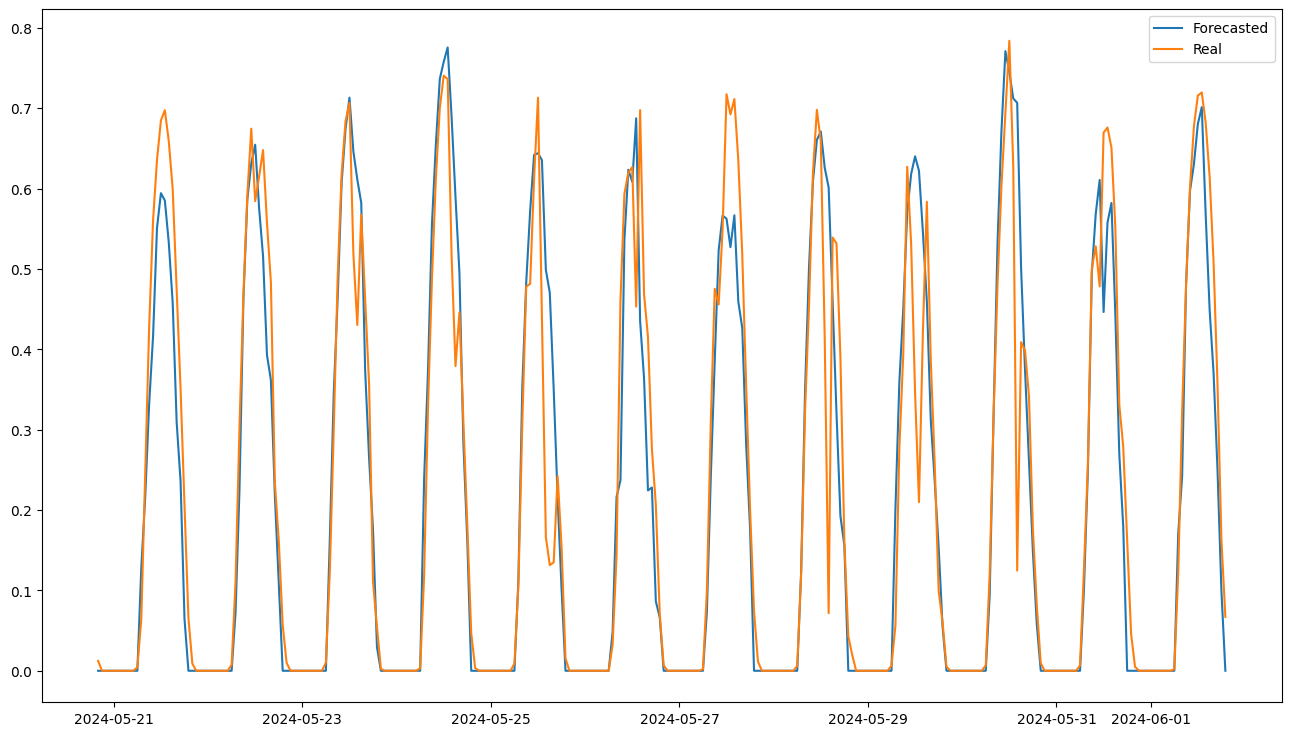

In [46]:
plt.figure(figsize=(16, 9))
plt.plot(test_results_kwh["Val Predictions"][14:302], label="Forecasted")
plt.plot(test_results_kwh["Real Data"][14:302], label="Real")
plt.legend()
plt.show()


In [47]:
mse_kwh = mean_squared_error(test_results_kwh["Real Data"], test_results_kwh["Val Predictions"])
print(f"Mean Squared Error = {round(mse_kwh, 5)} \nRoot Mean Squared Error = {round(np.sqrt(mse_kwh), 5)}")

ss_total = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Real Data"].mean()) ** 2)
residual = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Val Predictions"]) ** 2)
r_squared_kwh = 1 - (residual / ss_total)

r_squared_kwh, mse_kwh    #0.92

Mean Squared Error = 0.00534 
Root Mean Squared Error = 0.07306


(0.9187661910108399, 0.005338408243114054)